Local final project notebook

### Introduction

The NBA has evolved drastically over the years. The newest era being controlled by the three pointer. However, at a time, there was no three pointer, only added in 1979. Since then, the amount of three's being taken per game has been on an incline, especially since the greatest shooter of all time, Stephen Curry, reached his prime in the league. What I wish to analyze is the variance of efficiency throughout the different teams shooting teams in the NBA. Furthermore, I want to find out if there is a correlation between the three point percentage for a team and their success throughout the season. These answers can be used for multiple reasons, for example, a team with a lower efficiency of threes can try to align their play style to a team that shoots threes at a very efficient rate. To add on, the second question can give teams a better idea on how many threes to really take per game to make the most out of the extra point and give them the competitive edge.

### Data collection

I am going to use a websites called teamrankings.com to get the team names, then the stats of each teams three pointers attempted, three point percentage, and the offensive efficiency. I will webscrape for all of these values using BeautifulSoup and then use the pandas package to create a dataframe with all of the stats sorted by teams.

### Data Usage

I can use this data to answer my question by comparing the amount of three pointers attempted and the three point percentage and create graphs to see what teams are shooting the most efficiently. As for my second question, the 3 pointers attempted can be compared to the offensive efficiency of each team and determine which team uses the three point line to the most of its ability by using logistical regression graphs or something similar, a supervised machine learning technique. The methods of what graphs or techniques I might use to solve my questions may change as the year goes on as I do not know too many machine learning methods yet. If I learn any relevant unsupervised methods, I will try to incorpate them into my results as well.

In [9]:
#importing necessary packages
import requests
from bs4 import BeautifulSoup
import pandas as pd

#urls used 
url_3p_pct = "https://www.teamrankings.com/nba/stat/three-point-pct"
url_3pa = "https://www.teamrankings.com/nba/stat/three-pointers-attempted-per-game"
url_offensive_efficiency = "https://www.teamrankings.com/nba/stat/offensive-efficiency"

#scraping the team names and stats
def scrape_stats(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.content, 'html.parser')
    
    #getting table rows
    table = soup.find('table', {'class': 'tr-table'}).find('tbody').find_all('tr')
    
    #lists for team and stats
    teams = []
    stats = []
    
    #getting the team names and stats
    for row in table:
        columns = row.find_all('td')
        team = columns[1].text.strip()
        stat = columns[2].text.strip()
        
        #cleaning the data by removing the '%' symbol and convert the value to a float
        stat = stat.replace('%', '').strip()
        teams.append(team)
        stats.append(float(stat))
    
    return teams, stats

#scraping for 3pt %, 3pa, and offensive efficiency
teams_3p_pct, stats_3p_pct = scrape_stats(url_3p_pct)
teams_3pa, stats_3pa = scrape_stats(url_3pa)
teams_efficiency, stats_efficiency = scrape_stats(url_offensive_efficiency)

#making dfs for each dataset
df_3p_pct = pd.DataFrame({'Team': teams_3p_pct, '3P%': stats_3p_pct})
df_3pa = pd.DataFrame({'Team': teams_3pa, '3PA': stats_3pa})
df_efficiency = pd.DataFrame({'Team': teams_efficiency, 'ORtg': stats_efficiency})

#merging them all together
df_merged = pd.merge(pd.merge(df_3p_pct, df_3pa, on='Team'), df_efficiency, on='Team')

#sorting in alphabetical order
df_merged = df_merged.sort_values(by='Team').reset_index(drop=True)

#converting to csv file
df_merged.to_csv('nba_shooting_and_offense.csv', index=False)

print(df_merged)

            Team   3P%   3PA   ORtg
0        Atlanta  36.3  37.7  1.134
1         Boston  38.3  42.0  1.185
2       Brooklyn  36.2  36.7  1.095
3      Charlotte  35.5  34.0  1.062
4        Chicago  35.8  32.1  1.112
5      Cleveland  36.1  36.3  1.106
6         Dallas  36.8  38.2  1.134
7         Denver  36.9  31.3  1.140
8        Detroit  34.8  31.7  1.063
9   Golden State  37.9  38.8  1.138
10       Houston  35.2  36.1  1.107
11       Indiana  37.2  34.9  1.169
12   LA Clippers  38.1  33.1  1.144
13     LA Lakers  37.2  31.1  1.124
14       Memphis  34.6  37.8  1.037
15         Miami  36.8  33.8  1.100
16     Milwaukee  37.1  37.6  1.147
17     Minnesota  38.2  32.7  1.122
18   New Orleans  37.6  32.4  1.128
19      New York  37.0  35.3  1.141
20     Okla City  38.5  34.2  1.150
21       Orlando  34.8  31.5  1.092
22  Philadelphia  36.4  33.5  1.128
23       Phoenix  38.1  32.3  1.135
24      Portland  34.5  33.2  1.045
25    Sacramento  36.6  39.3  1.133
26   San Antonio  34.7  36.4

My goal, make correlation graphs between 3pa and offensive efficieny, and 3p % and offensive efficieny

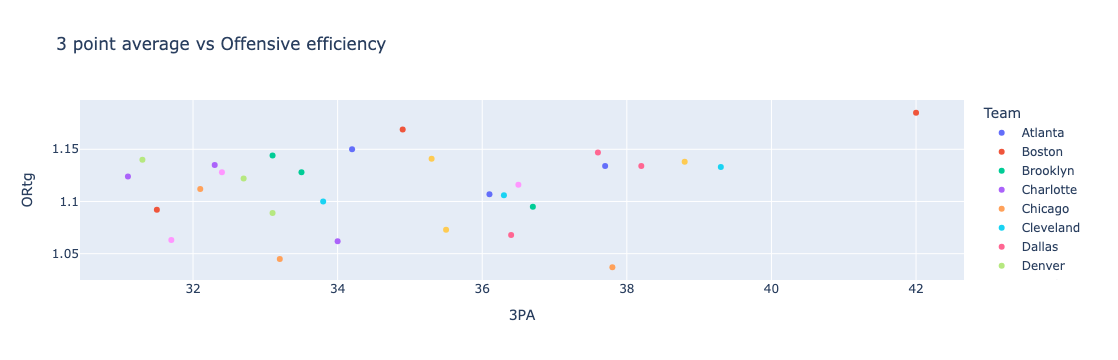

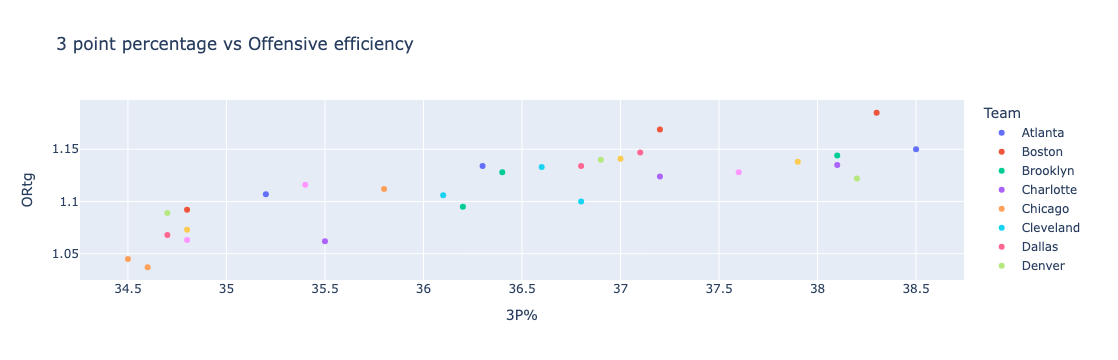

In [14]:
import plotly.express as px
import seaborn as sns

one=px.scatter(df_merged, x='3PA', y='ORtg', color='Team', hover_data=['3PA', 'ORtg' ,'Team'], title='3 point average vs Offensive efficiency')
one.show()

two=px.scatter(df_merged, x='3P%', y='ORtg', color='Team', hover_data=['3PA', 'ORtg' ,'Team'], title='3 point percentage vs Offensive efficiency')
two.show()

### Inference

So what can we see from these graphs ? I would say the most important difference in the two are the general shapes that our data points make. The top graph has an almost rectangle shape from its points, and it has one extremely far outlier, Boston, on the top right. Almost showing that there is no pattern to be seen between 3-point averages and offensive efficiency. On the other hand the bottom graphs has a relatively linear shape from its data points. Teams like Washington and Detroit with 3P% around 34.5% hover around 1.07 ORtg. While on the other hand, teams like boston and Oklahoma city, with higher 3P% around 38, consistently hover around 1.15 ORtg. This pattern tracks for pretty much all of the points, with no strong outliers besides maybe Charlotte. 